#Random


Random


Scikit-Learn version: 1.6.1


Saving bank-additional-full-updated-new.csv to bank-additional-full-updated-new (2).csv


[I 2025-05-09 11:35:56,010] A new study created in memory with name: no-name-6697293c-5a3d-4ec7-ba9c-393f56402735
[I 2025-05-09 11:36:40,968] Trial 0 finished with value: 0.9927329470797787 and parameters: {'n_estimators': 254, 'max_depth': 29, 'min_samples_split': 6, 'max_features': 'log2'}. Best is trial 0 with value: 0.9927329470797787.
[I 2025-05-09 11:37:04,951] Trial 1 finished with value: 0.952380641024232 and parameters: {'n_estimators': 71, 'max_depth': 5, 'min_samples_split': 9, 'max_features': None}. Best is trial 0 with value: 0.9927329470797787.
[I 2025-05-09 11:37:46,219] Trial 2 finished with value: 0.9920518224909975 and parameters: {'n_estimators': 244, 'max_depth': 22, 'min_samples_split': 7, 'max_features': 'log2'}. Best is trial 0 with value: 0.9927329470797787.
[I 2025-05-09 11:38:17,662] Trial 3 finished with value: 0.9893488626079634 and parameters: {'n_estimators': 211, 'max_depth': 15, 'min_samples_split': 5, 'max_features': 'log2'}. Best is trial 0 with value:

Best trial:
  Best ROC-AUC: 0.9937743927231738
  Best Parameters: {'n_estimators': 119, 'max_depth': 28, 'min_samples_split': 2, 'max_features': 'log2'}
Test Accuracy: 0.9022
ROC-AUC: 0.9387
Precision: 0.5600
Recall: 0.6439
F1-score: 0.5990


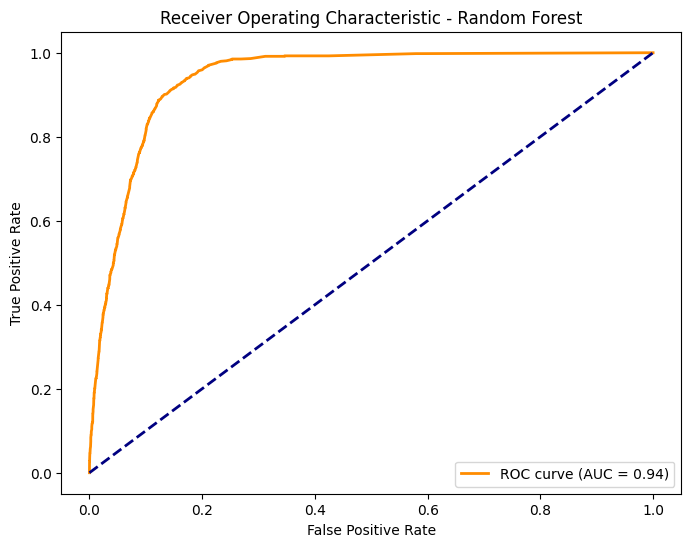

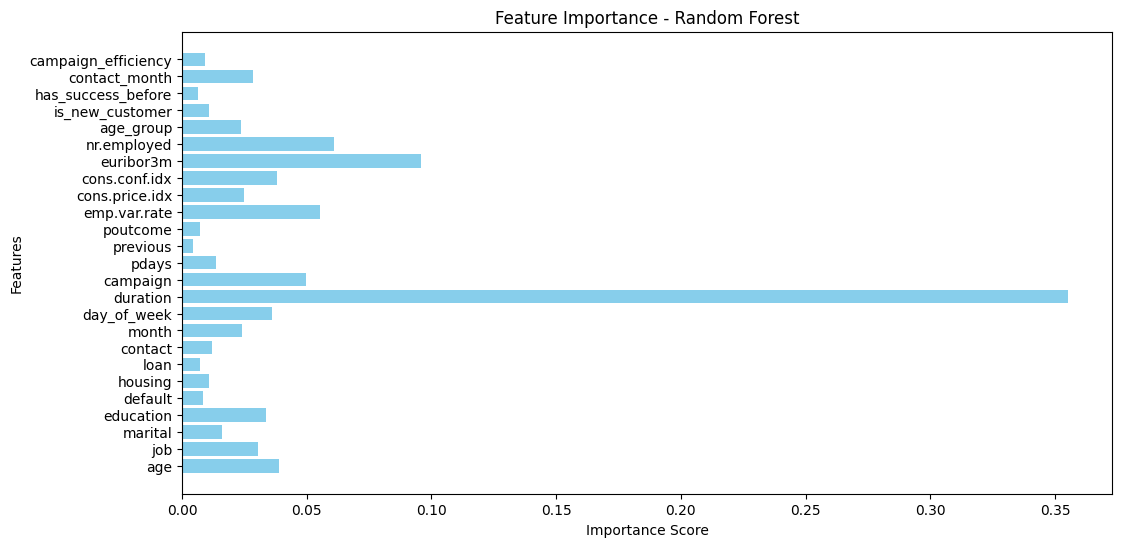

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ File đã được lưu và tải về.


In [ ]:
# Bước 1: Cài đặt các thư viện cần thiết
!pip install --upgrade tensorflow keras scikit-learn optuna imbalanced-learn

# Bước 2: Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (roc_auc_score, precision_score, recall_score, f1_score,
                             accuracy_score, roc_curve, auc, confusion_matrix, classification_report)
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from scipy import stats
from google.colab import files
import optuna
import sklearn
from sklearn.ensemble import RandomForestClassifier

# Bước 3: Kiểm tra phiên bản các thư viện
print("Scikit-Learn version:", sklearn.__version__)

# Bước 4: Upload file dataset từ Colab
uploaded = files.upload()

# Bước 5: Load data từ file CSV
df = pd.read_csv(list(uploaded.keys())[0])

# Bước 6: Xử lý dữ liệu ban đầu: Chuyển đổi cột 'y' thành số 1/0
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# Bước 7: Giữ lại cột 'name' và 'id' (để dùng sau này) và loại bỏ cột 'y' trong df_features
df_features = df.drop(['y'], axis=1)

# Bước 8: Chuyển đổi cột 'age_group' sang giá trị trung bình (theo mapping đã cho)
age_mapping = {
    '18-25': 21.5,
    '26-35': 30.5,
    '36-45': 40.5,
    '46-60': 53.0,
    '60+': 65.0
}
df_features['age_group'] = df_features['age_group'].map(age_mapping)

# Bước 9: Mã hóa các cột phân loại sử dụng LabelEncoder
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan',
                    'contact', 'month', 'day_of_week', 'poutcome', 'contact_month',
                    'is_new_customer', 'has_success_before', 'campaign_efficiency']
for col in categorical_cols:
    df_features[col] = LabelEncoder().fit_transform(df_features[col])

# Bước 10: Tách dữ liệu thành X (features) và y (label)
X = df_features.drop(['name', 'id'], axis=1)
y = df['y']

# Bước 11: Xử lý giá trị thiếu (NaN) với SimpleImputer và chuẩn hóa dữ liệu với StandardScaler
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Bước 12: Chia dữ liệu thành tập huấn luyện và tập test (80% huấn luyện, 20% test)
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(X, y, df.index, test_size=0.2, random_state=42)

# Bước 13: Cân bằng dữ liệu huấn luyện với SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Bước 14: Xử lý outliers trong tập huấn luyện bằng Z-score
z_scores = np.abs(stats.zscore(X_train_balanced))
X_train_no_outliers = X_train_balanced[(z_scores < 3).all(axis=1)]
y_train_no_outliers = y_train_balanced[(z_scores < 3).all(axis=1)]

# Bước 15: Định nghĩa hàm tạo mô hình Random Forest
def create_rf_model(n_estimators=100, max_depth=None, min_samples_split=2, max_features='sqrt'):
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )
    return model

# Bước 16: Định nghĩa hàm objective cho Optuna để tối ưu hóa hyperparameters của Random Forest
def objective(trial):
    # Đề xuất các giá trị hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 5, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])

    model = create_rf_model(n_estimators, max_depth, min_samples_split, max_features)

    # Sử dụng cross-validation 3-fold trên tập huấn luyện
    scores = cross_val_score(model, X_train_no_outliers, y_train_no_outliers, cv=3, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

# Bước 17: Chạy quá trình tối ưu hóa Bayesian với Optuna (20 trials) với mục tiêu maximize ROC-AUC
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)
print("Best trial:")
trial = study.best_trial
print("  Best ROC-AUC:", trial.value)
print("  Best Parameters:", trial.params)

# Bước 18: Dùng các tham số tối ưu để huấn luyện mô hình
best_params = trial.params
best_rf = create_rf_model(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    max_features=best_params['max_features']
)
best_rf.fit(X_train_no_outliers, y_train_no_outliers)

# Bước 19: Đánh giá mô hình trên tập test và vẽ ROC curve
y_pred_prob = best_rf.predict_proba(X_test)[:, 1]
roc_auc_value = roc_auc_score(y_test, y_pred_prob)
y_pred_label = (y_pred_prob >= 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred_label)
precision = precision_score(y_test, y_pred_label)
recall = recall_score(y_test, y_pred_label)
f1 = f1_score(y_test, y_pred_label)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {roc_auc_value:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

# Vẽ ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_value:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Random Forest')
plt.legend(loc="lower right")
plt.show()

# Vẽ Feature Importance
importances = best_rf.feature_importances_
feature_names = df_features.drop(['name', 'id'], axis=1).columns
plt.figure(figsize=(12, 6))
plt.barh(feature_names, importances, color='skyblue')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance - Random Forest')
plt.show()

# Bước 20: Lưu kết quả dự đoán vào file Excel và tải về
df_output = df.loc[idx_test, ['name', 'id', 'y']].copy()
df_output['Predicted_Label'] = y_pred_label
df_output['Predicted_Probability'] = y_pred_prob
file_path = 'lead_scoring_results_randomforest.xlsx'
df_output.to_excel(file_path, index=False)
files.download(file_path)
print("✅ File đã được lưu và tải về.")


#LightGBM

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 46.3 MB/s eta 0:00:00
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.18.0
    Uninstalling tensorboard-2.18.0:
      Successfully uninstalled tensorboard-2.18.0
  Attempting uninstall: lightgbm
    Found existing installation: lightgbm 4.5.0
    Uninstalling lightgbm-4.5.

Saving bank-additional-full-updated-new.csv to bank-additional-full-updated-new.csv


[I 2025-05-09 10:41:02,510] A new study created in memory with name: no-name-ac15cc11-b94c-4f02-b87b-488a3a3f78eb
<ipython-input-1-6a2ee55196a6>:95: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-3, 0.1)
[I 2025-05-09 10:41:29,616] Trial 0 finished with value: 0.9663674457515214 and parameters: {'num_leaves': 35, 'n_estimators': 255, 'max_depth': 6, 'learning_rate': 0.006189962563019464, 'min_child_samples': 40}. Best is trial 0 with value: 0.9663674457515214.
<ipython-input-1-6a2ee55196a6>:95: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-3, 0.1)
[I 

Best trial:
  Best ROC-AUC: 0.9933502738848966
  Best Parameters: {'num_leaves': 54, 'n_estimators': 125, 'max_depth': 13, 'learning_rate': 0.07682677540469646, 'min_child_samples': 13}
[LightGBM] [Info] Number of positive: 23916, number of negative: 25332
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006852 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5383
[LightGBM] [Info] Number of data points in the train set: 49248, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.485624 -> initscore=-0.057521
[LightGBM] [Info] Start training from score -0.057521


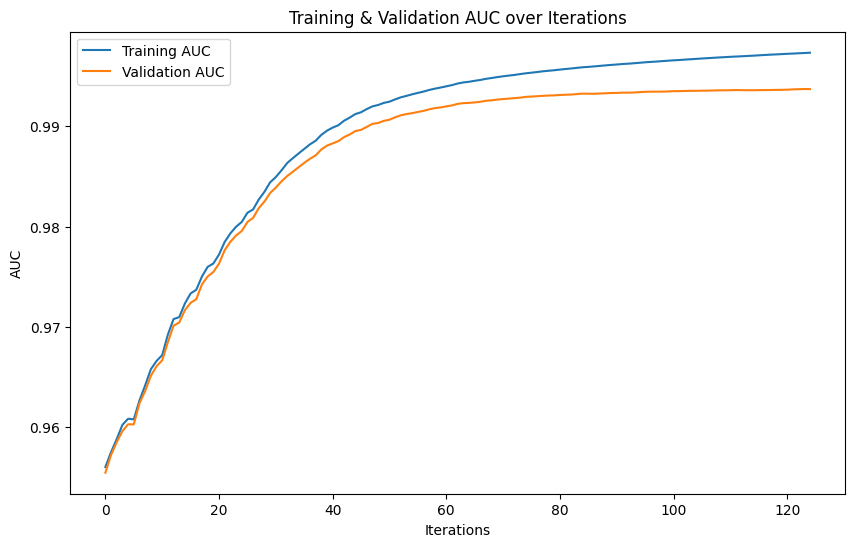

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Test Accuracy: 0.9116
ROC-AUC: 0.9457
Precision: 0.6053
Recall: 0.6364
F1-score: 0.6204


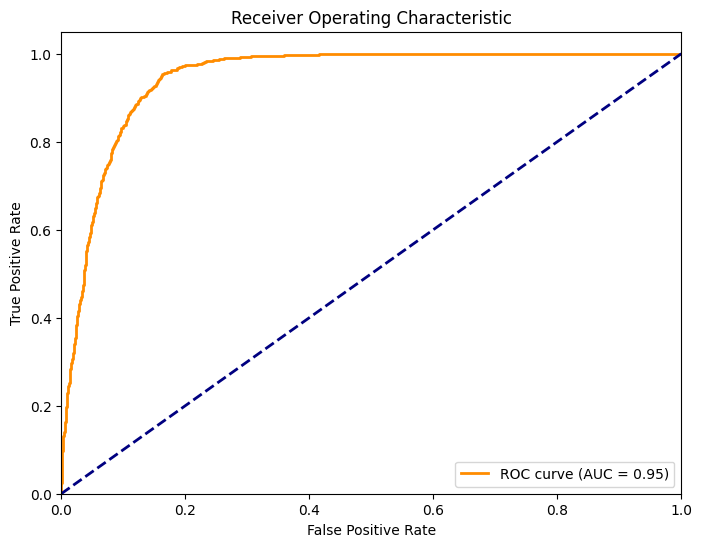

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ File đã được lưu và tải về.


In [ ]:
# Bước 1: Cài đặt các thư viện cần thiết
!pip install --upgrade tensorflow keras scikit-learn optuna imbalanced-learn lightgbm

# Bước 2: Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (roc_auc_score, precision_score, recall_score, f1_score,
                             accuracy_score, roc_curve, auc, confusion_matrix, classification_report)
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from scipy import stats
from google.colab import files
import optuna
import sklearn
import lightgbm as lgb

# Bước 3: Kiểm tra phiên bản các thư viện
print("Scikit-Learn version:", sklearn.__version__)

# Bước 4: Upload file dataset từ Colab
uploaded = files.upload()

# Bước 5: Load data từ file CSV
df = pd.read_csv(list(uploaded.keys())[0])

# Bước 6: Xử lý dữ liệu ban đầu: Chuyển đổi cột 'y' thành số 1/0
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# Bước 7: Giữ lại cột 'name' và 'id' (để dùng sau này) và loại bỏ cột 'y' trong df_features
df_features = df.drop(['y'], axis=1)

# Bước 8: Chuyển đổi cột 'age_group' sang giá trị trung bình (theo mapping đã cho)
age_mapping = {
    '18-25': 21.5,
    '26-35': 30.5,
    '36-45': 40.5,
    '46-60': 53.0,
    '60+': 65.0
}
df_features['age_group'] = df_features['age_group'].map(age_mapping)

# Bước 9: Mã hóa các cột phân loại sử dụng LabelEncoder
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan',
                    'contact', 'month', 'day_of_week', 'poutcome', 'contact_month',
                    'is_new_customer', 'has_success_before', 'campaign_efficiency']
for col in categorical_cols:
    df_features[col] = LabelEncoder().fit_transform(df_features[col])

# Bước 10: Tách dữ liệu thành X (features) và y (label)
X = df_features.drop(['name', 'id'], axis=1)
y = df['y']

# Bước 11: Xử lý giá trị thiếu (NaN) với SimpleImputer và chuẩn hóa dữ liệu với StandardScaler
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Bước 12: Chia dữ liệu thành tập huấn luyện và tập test (80% huấn luyện, 20% test),
#         lưu lại chỉ số để gán kết quả đúng sau này
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42)

# Bước 13: Cân bằng dữ liệu huấn luyện với SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Bước 14: Xử lý outliers trong tập huấn luyện bằng Z-score
z_scores = np.abs(stats.zscore(X_train_balanced))
X_train_no_outliers = X_train_balanced[(z_scores < 3).all(axis=1)]
y_train_no_outliers = y_train_balanced[(z_scores < 3).all(axis=1)]

# Bước 15: Định nghĩa hàm tạo mô hình LightGBM cho phân loại (sử dụng API scikit-learn)
def create_lgb_model(num_leaves=31, n_estimators=100, max_depth=-1, learning_rate=0.1, min_child_samples=20):
    model = lgb.LGBMClassifier(
        num_leaves=num_leaves,
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        min_child_samples=min_child_samples,
        random_state=42,
        n_jobs=-1
    )
    return model

# Bước 16: Định nghĩa hàm objective cho Optuna để tối ưu hóa hyperparameters của LightGBM
def objective(trial):
    # Đề xuất các giá trị hyperparameters
    num_leaves = trial.suggest_int('num_leaves', 20, 80)
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 5, 30)
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-3, 0.1)
    min_child_samples = trial.suggest_int('min_child_samples', 10, 50)

    model = create_lgb_model(
        num_leaves=num_leaves,
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        min_child_samples=min_child_samples
    )

    # Sử dụng cross-validation 3-fold trên tập huấn luyện đã qua xử lý outliers
    scores = cross_val_score(
        model,
        X_train_no_outliers,
        y_train_no_outliers,
        cv=3,
        scoring='roc_auc',
        n_jobs=-1
    )
    return scores.mean()

# Bước 17: Chạy quá trình tối ưu hóa Bayesian với Optuna (20 trials) với mục tiêu maximize ROC-AUC
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)
print("Best trial:")
trial = study.best_trial
print("  Best ROC-AUC:", trial.value)
print("  Best Parameters:", trial.params)

# Bước 18: Huấn luyện lại mô hình sử dụng các tham số tối ưu trên tập huấn luyện (sau xử lý outliers)
#         Để theo dõi quá trình huấn luyện, ta tách thêm tập validation từ X_train_no_outliers
X_tr, X_val, y_tr, y_val = train_test_split(X_train_no_outliers, y_train_no_outliers, test_size=0.1, random_state=42)
best_params = trial.params
best_lgb = create_lgb_model(
    num_leaves=best_params['num_leaves'],
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    learning_rate=best_params['learning_rate'],
    min_child_samples=best_params['min_child_samples']
)

# Sử dụng callback để thu thập kết quả đánh giá (record_evaluation)
from lightgbm.callback import record_evaluation
eval_hist = {}
best_lgb.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    eval_metric='auc',
    callbacks=[record_evaluation(eval_hist)]
)

# Vẽ sơ đồ Training & Validation AUC theo các vòng lặp (nếu có dữ liệu)
if 'training' in eval_hist and 'auc' in eval_hist['training']:
    train_auc = eval_hist['training']['auc']
    val_auc = eval_hist['valid_1']['auc']  # valid_1 tương ứng với tập validation
    plt.figure(figsize=(10, 6))
    plt.plot(train_auc, label='Training AUC')
    plt.plot(val_auc, label='Validation AUC')
    plt.xlabel('Iterations')
    plt.ylabel('AUC')
    plt.title('Training & Validation AUC over Iterations')
    plt.legend()
    plt.show()
else:
    print("Khởi tạo eval_hist không thành công hoặc không có dữ liệu để vẽ sơ đồ.")

# Bước 19: Đánh giá mô hình trên tập test và vẽ ROC curve
y_pred_prob = best_lgb.predict_proba(X_test)[:, 1]
roc_auc_value = roc_auc_score(y_test, y_pred_prob)
y_pred_label = (y_pred_prob >= 0.5).astype(int)
accuracy = accuracy_score(y_test, y_pred_label)
precision_value = precision_score(y_test, y_pred_label)
recall_value = recall_score(y_test, y_pred_label)
f1_value = f1_score(y_test, y_pred_label)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {roc_auc_value:.4f}")
print(f"Precision: {precision_value:.4f}")
print(f"Recall: {recall_value:.4f}")
print(f"F1-score: {f1_value:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc_curve = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_curve:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Bước 20: Lưu kết quả dự đoán trên tập test vào file Excel và tải về
df_output = df.loc[idx_test, ['name', 'id', 'y']].copy()
df_output['Predicted_Label'] = y_pred_label
df_output['Predicted_Probability'] = y_pred_prob
file_path = 'lead_scoring_results_lightgbm.xlsx'
df_output.to_excel(file_path, index=False)
files.download(file_path)
print("✅ File đã được lưu và tải về.")
